In [3]:
from spiderwarp.optimized_steane_perm_state_prep import mqt_steane_opt
from spiderwarp.utils import _layer_cnot_circuit
from spiderwarp.csscode import CSSCode

%load_ext autoreload
%autoreload 2

In [12]:
code_name = "19_1_5"
code = CSSCode.load_code("MQT", code_name)
og_circ, circ, M = mqt_steane_opt(code_name, optimise_c2=True)

Optimised C_2: 38 -> 29
Optimised C_4: 38 -> 30
Optimised C_3; C_4:68 -> 43


Num qubits: 57


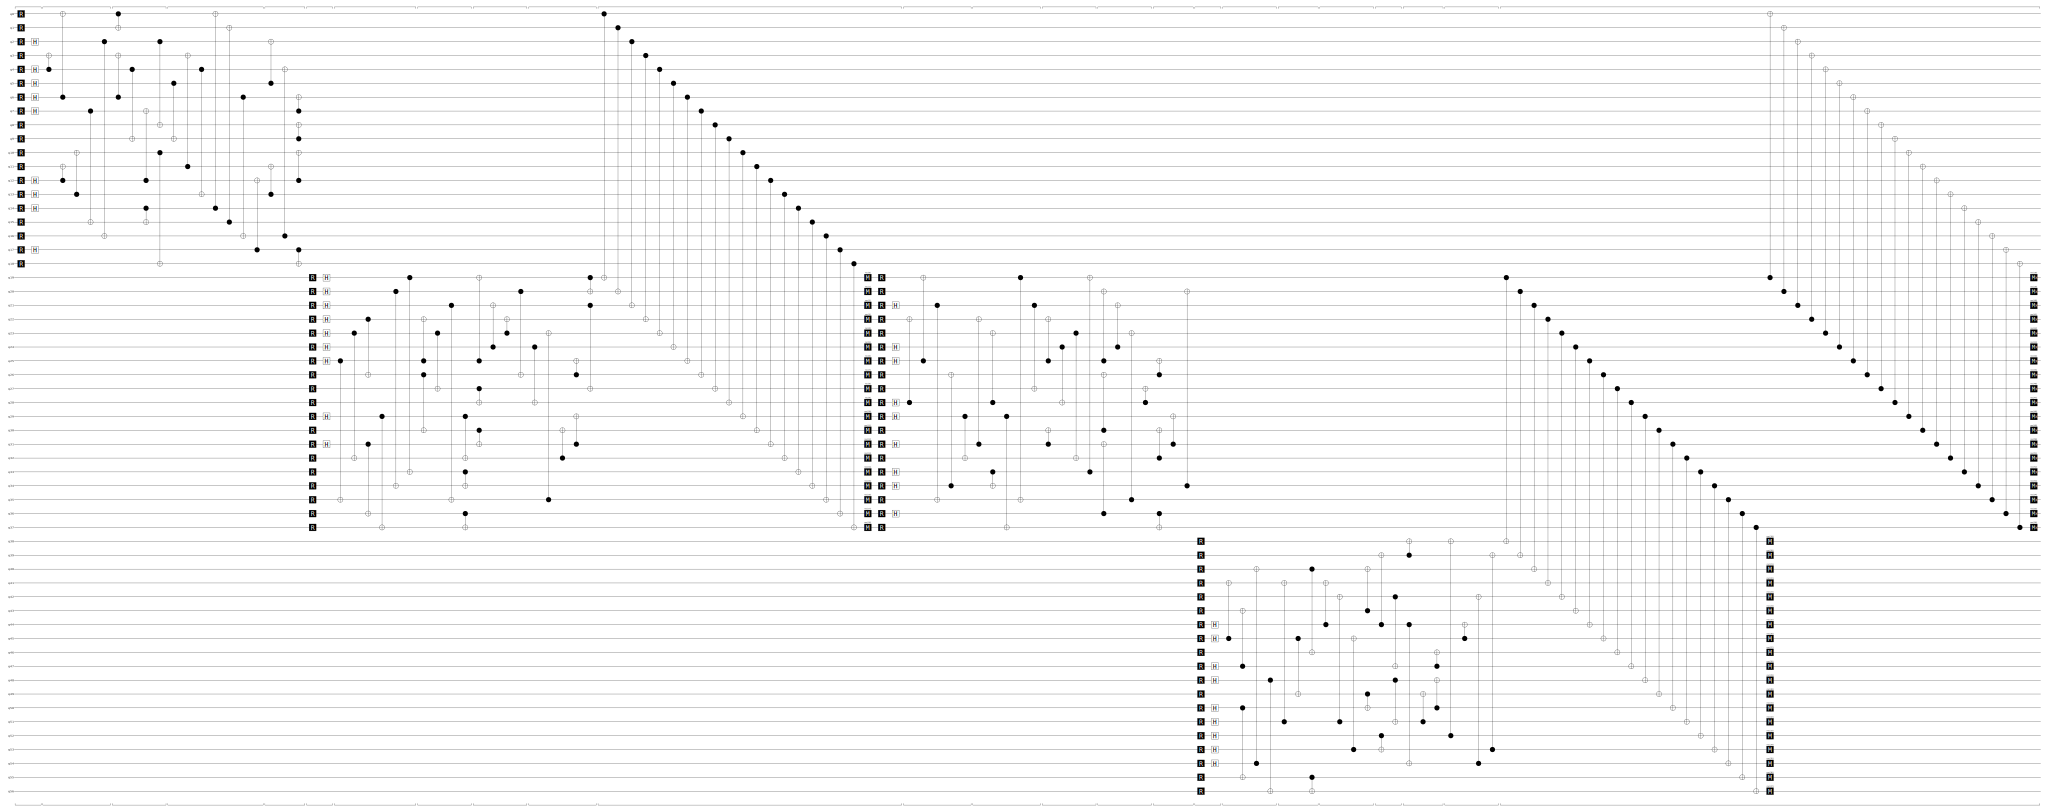

In [13]:
print("Num qubits:", og_circ.num_qubits)
og_circ.diagram('timeline-svg')

Num qubits: 43


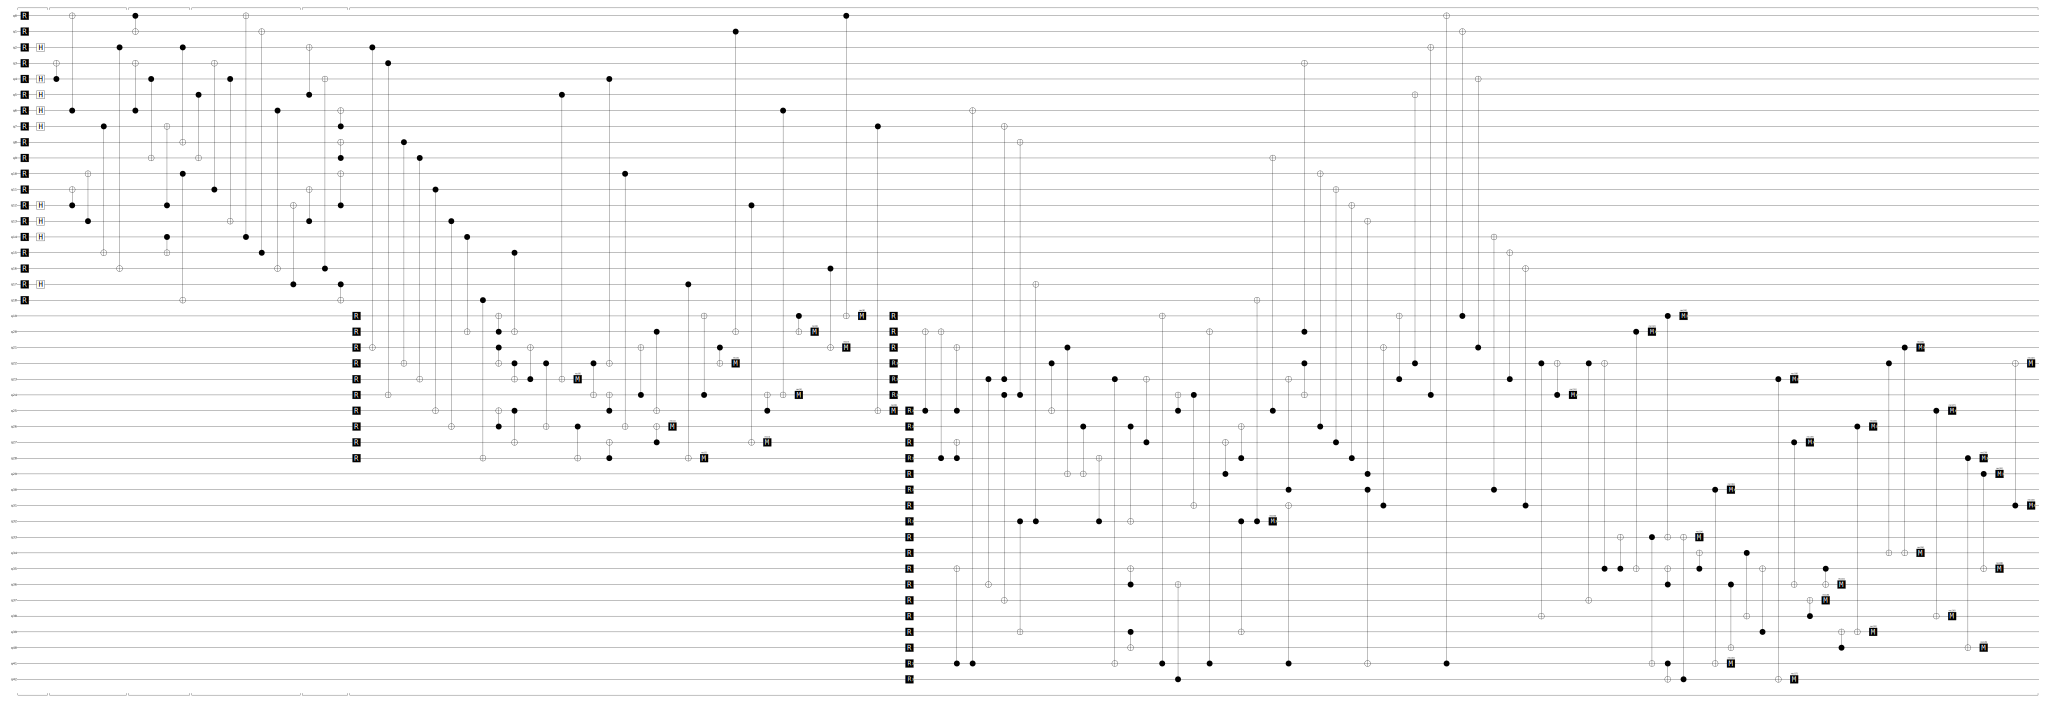

In [14]:
print("Num qubits:", circ.num_qubits)
circ.diagram('timeline-svg')

In [15]:
raw_cnots = [l for (name, l, _) in circ.flattened_operations() if name == "CX"]
cnots = [(ops[i], ops[i + 1]) for ops in raw_cnots for i in range(0, len(ops), 2)]
print("Num CX:", len(cnots))
print("Num qubits:", circ.num_qubits)
layered_cnots = _layer_cnot_circuit(cnots)
print("Depth:", len(layered_cnots))
print("MM", M)

Num CX: 142
Num qubits: 43
Depth: 32
MM {0: 5, 1: 10, 2: 17, 3: 4, 4: 12, 5: 6, 6: 1, 7: 16, 8: 0, 9: 7, 10: 56, 11: 40, 12: 41, 13: 39, 14: 20, 15: 33, 16: 52, 17: 34, 18: 53, 19: 49, 20: 27, 21: 30, 22: 29, 23: 48, 24: 23, 25: 42, 26: 28, 27: 47, 28: 31, 29: 50, 30: 32, 31: 51, 32: 35, 33: 54}


In [18]:
import numpy as np

circuit = circ.copy()
circuit.append("M", range(code.H_x.shape[1]))
smplr = circuit.compile_sampler()
samples = smplr.sample(10)
raw_syndrome_measurements = samples[:,:-code.H_x.shape[1]]
raw_measurements = samples[:, -code.H_x.shape[1]:]

effective_H_x = np.kron(np.eye(3, dtype=np.uint8), code.H_x)
effective_H_x = effective_H_x[:, tuple(M.values())].copy()
# for f in effective_H_x.T:
#     print(f)
print("Full rank:", np.linalg.matrix_rank(effective_H_x) == min(effective_H_x.shape))

Full rank: True


In [19]:
distillation_syndromes = raw_syndrome_measurements @ effective_H_x.T % 2
print(distillation_syndromes)

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


In [31]:
from mqt.qecc.circuit_synthesis import LutDecoder
from mqt.qecc import CSSCode as MQTCSSCode


mqt_code = MQTCSSCode(Hx=code.H_x, Hz=code.H_z, distance=code.d)
max_weight = (code.d - 1) // 2
decoder = LutDecoder(mqt_code, max_decodable_weight=None)
syndromes = raw_measurements @ code.H_x.T % 2
corrections = decoder.batch_decode_z(syndromes)
print(syndromes)

[[0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]]


In [34]:
# 3. Post-selection: Find valid rows
# Since valid correction arrays only contain 0s and 1s, checking if the
# minimum value in the row is -1 instantly flags the sentinels.
valid_mask = np.min(corrections, axis=1) != -1

# 4. Filter the raw data
valid_measurements = raw_measurements[valid_mask]
valid_corrections = corrections[valid_mask]

# 5. Apply corrections safely
corrected_measurements = valid_measurements ^ valid_corrections
predicted_logicals = corrected_measurements @ code.L_x.T % 2

# Optional: Track your post-selection discard rate
discarded_shots = len(syndromes) - len(valid_corrections)
print(f"Discarded {discarded_shots} uncorrectable shots.")

# If any logical observable failed to be corrected in a shot, that shot is a logical error
incorrect_predictions = np.any(predicted_logicals, axis=1)
LER = np.average(incorrect_predictions) if len(incorrect_predictions) > 0 else 0.0
print(LER)

Discarded 0 uncorrectable shots.
0.0


In [39]:
code.H_x.shape

(8, 17)

In [44]:
print(code.H_x)

[[0 0 0 0 0 1 0 0 0 1 0 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 1 0]
 [0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1]
 [0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1]
 [0 0 0 0 1 1 1 1 1 0 1 1 0 0 0 0 1]
 [0 1 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 1 0]
 [1 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0]]


In [51]:
effective_H_x.shape

(24, 33)